# 04 Natural Images Comparison

Natural images are different from full-field gratings: translating the image changes which edges, textures, and luminance patterns fall on each RF subfield. This can strongly alter population responses even when grating-derived PO is stable.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.utils import load_config, rng_from_config
from src.sampling import sample_population
from src.natural_images import load_natural_images
from src.simulation import run_natural_shift_grid, run_grating_shift_grid
from src.plotting import set_plot_style, heatmap_from_table, plot_response_matrix

set_plot_style()
fig_dir = ROOT / 'results/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

cfg = load_config(ROOT / 'configs/default.yaml', debug=True)
rng = rng_from_config(cfg)
pop = sample_population(cfg, rng)
images = load_natural_images(cfg, rng)
natural = run_natural_shift_grid(pop, images, cfg, rng)
grating = run_grating_shift_grid(pop, cfg, rng)
print(images.shape)

(8, 48, 48)


## Image Inputs

If no image folder is configured, the loader creates procedural naturalistic grayscale images. This keeps the project runnable while preserving the same response machinery used for real image folders.

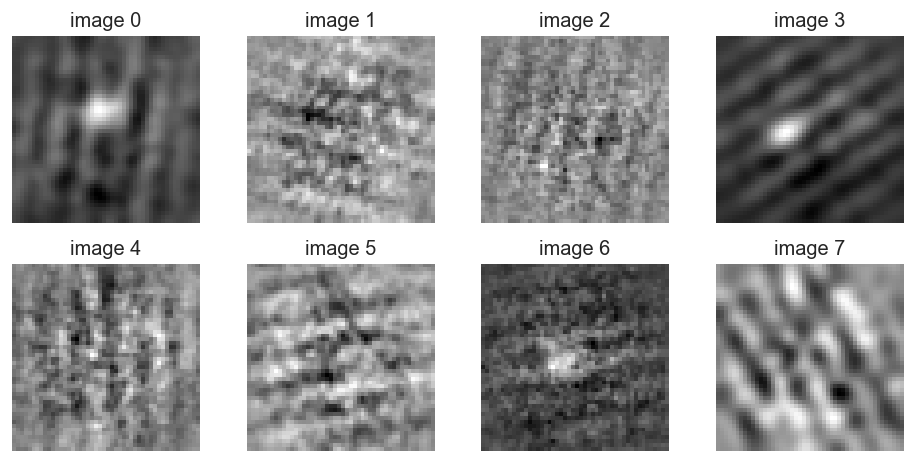

In [2]:
n_show = min(8, len(images))
fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, img, idx in zip(axes.ravel(), images[:n_show], range(n_show)):
    ax.imshow(img, cmap='gray', origin='lower')
    ax.set_title(f'image {idx}')
    ax.axis('off')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook04_image_montage.png', bbox_inches='tight')

## Natural-Image Stability Heat Maps

The raw population correlation asks whether the same image evokes the same neural pattern after gaze shift. RDM similarity asks whether the image-to-image representational geometry is preserved even if raw responses change.

In [3]:
heatmap_from_table(natural['summary'], 'population_response_correlation', fig_dir / 'notebook04_population_corr.png', title='Population response correlation')
heatmap_from_table(natural['summary'], 'rdm_similarity_to_baseline', fig_dir / 'notebook04_rdm_similarity.png', title='RDM similarity')
heatmap_from_table(natural['summary'], 'median_relative_response_change', fig_dir / 'notebook04_relative_change.png', title='Relative response change')
display(natural['summary'].tail())

,gaze_az_deg,gaze_el_deg,population_response_correlation,median_per_neuron_response_change,median_relative_response_change,fraction_large_response_change,rdm_similarity_to_baseline,image_discriminability,shifted_image_discriminability
31,1.0,5.0,0.126645,6.041063,1.013444,0.98750,0.256652,0.990294,0.989501
32,2.0,5.0,0.054100,6.101773,1.006728,0.98750,0.208902,0.990294,0.978878
33,3.0,5.0,-0.020453,5.961617,1.024346,0.99375,0.216811,0.990294,0.978832
34,4.0,5.0,-0.065549,6.392169,1.027406,1.00000,0.285637,0.990294,0.978614
35,5.0,5.0,-0.083027,6.137654,1.021825,1.00000,0.323124,0.990294,0.968466


## Response Matrices

These matrices show image-by-neuron responses at baseline and at the largest gaze offset. The visual difference is often much larger than the grating PO shift would suggest.

In [4]:
plot_response_matrix(natural['baseline_response'], fig_dir / 'notebook04_baseline_response_matrix.png', title='Natural-image responses, baseline')
plot_response_matrix(natural['far_state']['response'], fig_dir / 'notebook04_far_response_matrix.png', title='Natural-image responses, largest offset')

## Bridge to Grating Sensitivity

Here we merge grating and natural-image metrics by gaze shift. A key result is that natural-image response correlations can drop strongly even when median grating `|ΔPO|` is modest.

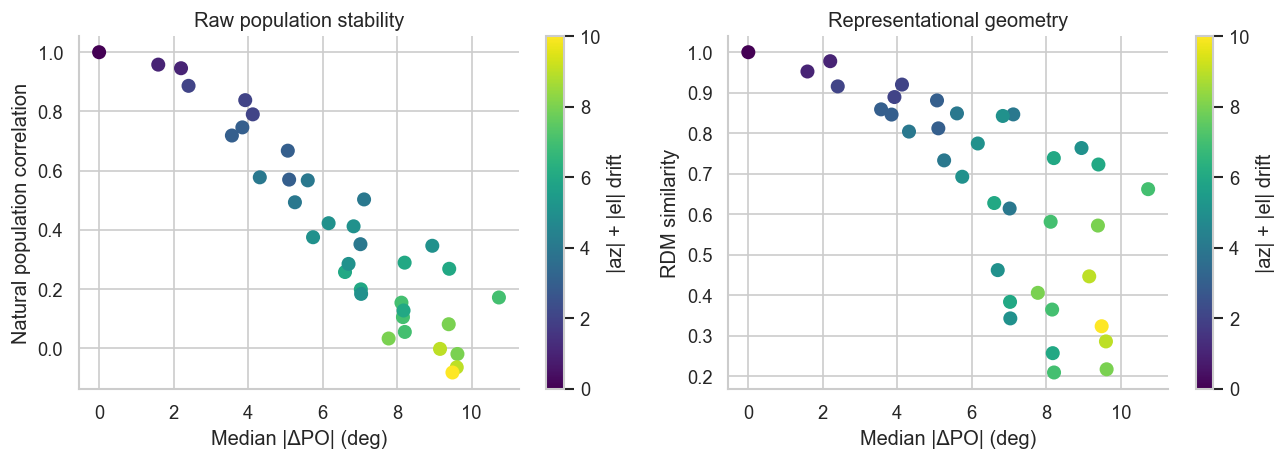

In [5]:
bridge = grating['summary'].merge(natural['summary'], on=['gaze_az_deg', 'gaze_el_deg'])
bridge['gaze_radius'] = bridge.gaze_az_deg.abs() + bridge.gaze_el_deg.abs()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sc = axes[0].scatter(bridge.median_abs_delta_po_deg, bridge.population_response_correlation, c=bridge.gaze_radius, cmap='viridis', s=55)
axes[0].set_xlabel('Median |ΔPO| (deg)'); axes[0].set_ylabel('Natural population correlation')
axes[0].set_title('Raw population stability')
plt.colorbar(sc, ax=axes[0], label='|az| + |el| drift')
sc2 = axes[1].scatter(bridge.median_abs_delta_po_deg, bridge.rdm_similarity_to_baseline, c=bridge.gaze_radius, cmap='viridis', s=55)
axes[1].set_xlabel('Median |ΔPO| (deg)'); axes[1].set_ylabel('RDM similarity')
axes[1].set_title('Representational geometry')
plt.colorbar(sc2, ax=axes[1], label='|az| + |el| drift')
plt.tight_layout()
plt.savefig(fig_dir / 'notebook04_grating_natural_bridge.png', bbox_inches='tight')

## Takeaway

Natural-image responses can be more gaze-sensitive than grating PO estimates because image translations change local RF drive directly. This is the representational-drift framing: the population code can move even if the grating-derived PO axis appears stable.